# Spatio-Temporal Graph Modeling for Pest Prediction

Welcome to your Spatio-Temporal Graph Neural Network (STGNN) project! 

### What are we trying to do?
Our goal is to **predict future pest counts** across different districts in India. 

### Why Spatio-Temporal?
1. **Spatial (Space):** Pests don't respect district borders. If a neighboring district has a high pest population, your district is at high risk. We represent this as a **Graph**, where:
   - **Nodes:** Districts (543 unique districts).
   - **Edges:** Connections between districts based on geographical proximity (already computed in `edge_index.npy`).
2. **Temporal (Time):** Pest populations follow trends over time. If there were many pests last month, there might be many this month. We represent this using **Time Steps** (months from Jan 2013 to Sep 2017).

### The Plan:
1. Load the historical pest data and the graph structure.
2. Reshape the data into a Spatio-Temporal matrix `(Districts × Months)`.
3. Create "Sliding Windows" (e.g., use the past 6 months to predict the next 1 month).
4. Build and train a Neural Network that learns from both the graph (space) and the sequence (time).

## 1. Load and Inspect Merged Dataset
First, let's import the necessary libraries and load the main dataset (`monthly_spatiotemporal_data.csv`) and the graph edges (`edge_index.npy`, `edge_weight.npy`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

# Load the main dataset
df = pd.read_csv('monthly_spatiotemporal_data.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

# Load the graph edges and weights
edge_index = np.load('edge_index.npy')
edge_weight = np.load('edge_weight.npy')
print(f"Edge Index shape: {edge_index.shape}")
print(f"Edge Weight shape: {edge_weight.shape}")

Dataset shape: (19248, 6)


,district,year_month,pest_count,latitude,longitude,district_id
0,AHMADABAD,2013-01-01,1,23.021624,72.579707,5
1,AHMADNAGAR,2013-01-01,5,19.250000,74.750000,6
2,AJMER,2013-01-01,6,26.469100,74.639000,7
3,ALIGARH,2013-01-01,1,27.881541,78.069022,10
4,ALLAHABAD,2013-01-01,5,25.438130,81.833800,12


Edge Index shape: (2, 4306)
Edge Weight shape: (4306,)


## 2. Spatio-Temporal Feature Engineering
We need to convert the tabular data into a Spatio-Temporal matrix of shape `(num_nodes, num_time_steps)`.
- **Rows:** Districts (Nodes)
- **Columns:** Months (Time Steps)
- **Values:** Pest Count

We will fill any missing values with 0, assuming no record means 0 pests were found.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Pivot the dataframe to get districts as rows and time steps as columns
pivot_df = df.pivot(index='district_id', columns='year_month', values='pest_count')

# Fill missing values with 0 (assuming no record means 0 pests)
pivot_df = pivot_df.fillna(0)

print(f"Spatio-Temporal Matrix shape: {pivot_df.shape}")
# Rows = 543 districts, Columns = 57 months
display(pivot_df.head())

# Convert to numpy array for easier manipulation
data_matrix = pivot_df.values

# IMPORTANT: Normalize the data! Neural networks struggle with high variance raw counts.
scaler = MinMaxScaler()
# We scale the entire matrix. Reshape to 1D, scale, then reshape back.
data_matrix_scaled = scaler.fit_transform(data_matrix.reshape(-1, 1)).reshape(data_matrix.shape)
print("Data normalized using MinMaxScaler.")

Spatio-Temporal Matrix shape: (543, 57)


year_month,2013-01-01,2013-02-01,2013-03-01,2013-04-01,2013-05-01,2013-06-01,2013-07-01,2013-08-01,2013-09-01,2013-10-01,...,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01
district_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,21.0,24.0,15.0,14.0,0.0,22.0,0.0,...,31.0,40.0,67.0,63.0,0.0,24.0,21.0,21.0,24.0,15.0
1,0.0,0.0,0.0,25.0,27.0,18.0,18.0,8.0,7.0,5.0,...,42.0,53.0,118.0,124.0,98.0,0.0,31.0,43.0,0.0,30.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,...,29.0,21.0,33.0,0.0,8.0,2.0,3.0,0.0,64.0,49.0
3,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,10.0,6.0,0.0,5.0,10.0,0.0,13.0,47.0,23.0
4,0.0,1.0,0.0,11.0,7.0,7.0,0.0,11.0,9.0,4.0,...,19.0,12.0,5.0,16.0,0.0,0.0,19.0,27.0,31.0,25.0


Data normalized using MinMaxScaler.


## 3. Construct the Spatial Graph
The graph edges (`edge_index`) and weights (`edge_weight`) have already been computed based on the geographical distance between districts. We will convert them into PyTorch tensors so they can be used by our Neural Network.

In [3]:
# Convert graph edges to PyTorch tensors
edge_index_tensor = torch.LongTensor(edge_index)
edge_weight_tensor = torch.FloatTensor(edge_weight)

print(f"Edge Index Tensor shape: {edge_index_tensor.shape}")
print(f"Edge Weight Tensor shape: {edge_weight_tensor.shape}")

Edge Index Tensor shape: torch.Size([2, 4306])
Edge Weight Tensor shape: torch.Size([4306])


## 4. Prepare Temporal Sliding Windows
To train a model, we need to create input-output pairs. We will use a "sliding window" approach:
- **Input (X):** The past `T` months of pest counts for all districts.
- **Target (y):** The next `1` month of pest counts for all districts.

For example, if we use a window size of 6, we use Jan-Jun to predict Jul, then Feb-Jul to predict Aug, and so on.

In [9]:
def create_sliding_windows(data, window_size, horizon=1):
    """
    data: shape (num_nodes, num_time_steps)
    window_size: number of past time steps to use as input
    horizon: number of future time steps to predict
    """
    num_nodes, num_time_steps = data.shape
    X, y = [], []
    
    for i in range(num_time_steps - window_size - horizon + 1):
        # Input: past 'window_size' months for all nodes
        X.append(data[:, i : i + window_size])
        # Target: next 'horizon' month(s) for all nodes
        y.append(data[:, i + window_size : i + window_size + horizon])
        
    return np.array(X), np.array(y)

# Let's use 6 months of history to predict the next 1 month
window_size = 6
horizon = 1

# USE THE SCALED DATA HERE
X, y = create_sliding_windows(data_matrix_scaled, window_size, horizon)

print(f"X shape: {X.shape} -> (num_samples, num_nodes, window_size)")
print(f"y shape: {y.shape} -> (num_samples, num_nodes, horizon)")

# Split chronologically (e.g., first 80% for training, last 20% for testing)
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

X shape: (51, 543, 6) -> (num_samples, num_nodes, window_size)
y shape: (51, 543, 1) -> (num_samples, num_nodes, horizon)
Training samples: 40
Testing samples: 11


## 5. Define the Spatio-Temporal Graph Neural Network
We will build a simple Spatio-Temporal Graph Convolutional Network (STGCN).
- **Spatial Component:** A Graph Convolutional Network (GCN) layer to learn from neighboring districts.
- **Temporal Component:** An LSTM (Long Short-Term Memory) layer to learn from the sequence of past months.

*Note: This requires `torch_geometric`. If you don't have it installed, you can install it via `pip install torch_geometric`.*

In [10]:
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.nn import GCNConv
    HAS_PYG = True
except ImportError:
    print("PyTorch Geometric not found. Please install it using: pip install torch_geometric")
    HAS_PYG = False

if HAS_PYG:
    # 1. The Spatio-Temporal Model
    class STGNN(nn.Module):
        def __init__(self, hidden_channels, out_channels):
            super(STGNN, self).__init__()
            # Spatial Graph Convolution (processes 1 time step at a time)
            self.gcn = GCNConv(1, hidden_channels)
            # Temporal LSTM
            self.lstm = nn.LSTM(hidden_channels, hidden_channels, batch_first=True)
            # Final prediction layer
            self.linear = nn.Linear(hidden_channels, out_channels)

        def forward(self, x, edge_index, edge_weight):
            # x shape: (batch_size, num_nodes, window_size)
            batch_size, num_nodes, window_size = x.shape
            
            outputs = []
            for b in range(batch_size):
                # Process each time step through the GCN
                h_t = []
                for t in range(window_size):
                    # Extract time step t: shape (num_nodes, 1)
                    xt = x[b, :, t].unsqueeze(-1)
                    # Apply GCN
                    gcn_out = F.relu(self.gcn(xt, edge_index, edge_weight))
                    h_t.append(gcn_out)
                
                # Stack temporal features: (num_nodes, window_size, hidden_channels)
                h_t = torch.stack(h_t, dim=1)
                
                # Apply LSTM
                lstm_out, _ = self.lstm(h_t)
                
                # Take the output of the last time step
                last_out = lstm_out[:, -1, :]
                
                # Predict
                pred = self.linear(last_out)
                outputs.append(pred)
                
            return torch.stack(outputs)

    # 2. A Baseline Temporal-Only Model (to evaluate the "Spatio" part)
    class BaselineLSTM(nn.Module):
        def __init__(self, hidden_channels, out_channels):
            super(BaselineLSTM, self).__init__()
            self.lstm = nn.LSTM(1, hidden_channels, batch_first=True)
            self.linear = nn.Linear(hidden_channels, out_channels)

        def forward(self, x):
            # x shape: (batch_size, num_nodes, window_size)
            batch_size, num_nodes, window_size = x.shape
            
            outputs = []
            for b in range(batch_size):
                # Reshape for LSTM: (num_nodes, window_size, 1)
                xt = x[b].unsqueeze(-1)
                lstm_out, _ = self.lstm(xt)
                last_out = lstm_out[:, -1, :]
                pred = self.linear(last_out)
                outputs.append(pred)
                
            return torch.stack(outputs)
            
    print("Models defined successfully!")
    
    # Initialize the models
    hidden_channels = 64
    out_channels = horizon # Predicting next month
    
    stgnn_model = STGNN(hidden_channels, out_channels)
    lstm_model = BaselineLSTM(hidden_channels, out_channels)
    print("STGNN and Baseline LSTM initialized.")

Models defined successfully!
STGNN and Baseline LSTM initialized.


## 6. Train the Model
We will set up a training loop using Mean Squared Error (MSE) as our loss function and Adam as our optimizer.

Starting Training...
Epoch [10/100] | STGNN Loss: 0.0011 | LSTM Loss: 0.0011
Epoch [20/100] | STGNN Loss: 0.0010 | LSTM Loss: 0.0011
Epoch [30/100] | STGNN Loss: 0.0008 | LSTM Loss: 0.0010
Epoch [40/100] | STGNN Loss: 0.0008 | LSTM Loss: 0.0009
Epoch [50/100] | STGNN Loss: 0.0008 | LSTM Loss: 0.0008
Epoch [60/100] | STGNN Loss: 0.0007 | LSTM Loss: 0.0008
Epoch [70/100] | STGNN Loss: 0.0007 | LSTM Loss: 0.0008
Epoch [80/100] | STGNN Loss: 0.0007 | LSTM Loss: 0.0007
Epoch [90/100] | STGNN Loss: 0.0007 | LSTM Loss: 0.0007
Epoch [100/100] | STGNN Loss: 0.0007 | LSTM Loss: 0.0007


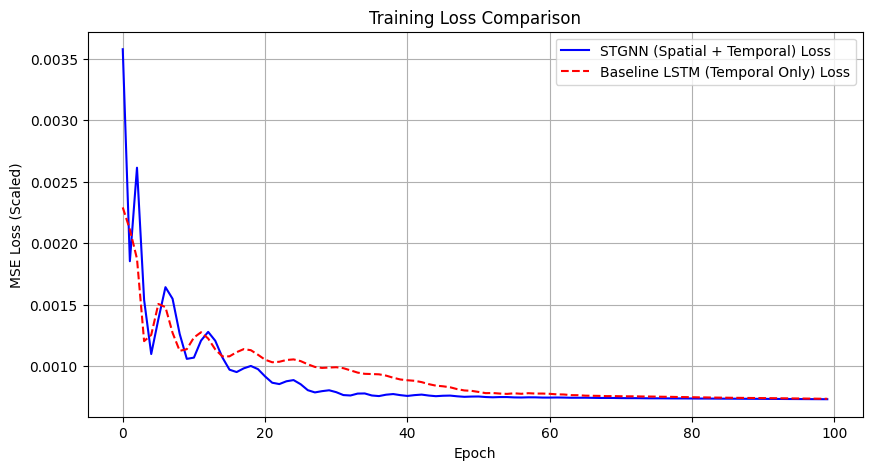

In [11]:
import torch.optim as optim

if HAS_PYG:
    # Define Loss and Optimizers
    criterion = nn.MSELoss()
    # Using AdamW for better weight decay handling
    opt_stgnn = optim.AdamW(stgnn_model.parameters(), lr=0.005)
    opt_lstm = optim.AdamW(lstm_model.parameters(), lr=0.005)
    
    epochs = 100 # Increased epochs for better learning
    stgnn_losses = []
    lstm_losses = []
    
    print("Starting Training...")
    for epoch in range(epochs):
        # --- Train STGNN ---
        stgnn_model.train()
        opt_stgnn.zero_grad()
        out_stgnn = stgnn_model(X_train_tensor, edge_index_tensor, edge_weight_tensor)
        loss_stgnn = criterion(out_stgnn, y_train_tensor)
        loss_stgnn.backward()
        opt_stgnn.step()
        stgnn_losses.append(loss_stgnn.item())
        
        # --- Train Baseline LSTM ---
        lstm_model.train()
        opt_lstm.zero_grad()
        out_lstm = lstm_model(X_train_tensor)
        loss_lstm = criterion(out_lstm, y_train_tensor)
        loss_lstm.backward()
        opt_lstm.step()
        lstm_losses.append(loss_lstm.item())
        
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | STGNN Loss: {loss_stgnn.item():.4f} | LSTM Loss: {loss_lstm.item():.4f}')
            
    # Plot training loss comparison
    plt.figure(figsize=(10, 5))
    plt.plot(stgnn_losses, label='STGNN (Spatial + Temporal) Loss', color='blue')
    plt.plot(lstm_losses, label='Baseline LSTM (Temporal Only) Loss', color='red', linestyle='--')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (Scaled)')
    plt.legend()
    plt.grid(True)
    plt.show()

## 7. Evaluate and Visualize Predictions
Finally, we will test our model on the unseen test data and visualize how well it predicts the pest counts for a specific district.

STGNN Test Loss (Scaled MSE): 0.0005
Baseline LSTM Test Loss (Scaled MSE): 0.0005

Visualizing District 195 (Highest pest count in test set)
STGNN R2 Score for District 195: -0.1736
Baseline LSTM R2 Score for District 195: -0.1533


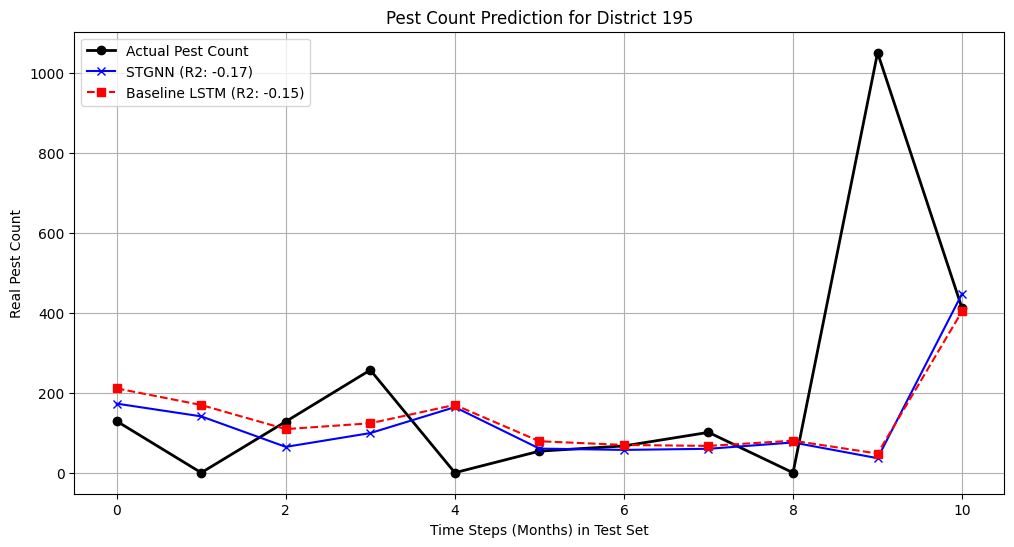

In [13]:
from sklearn.metrics import r2_score

if HAS_PYG:
    stgnn_model.eval()
    lstm_model.eval()
    with torch.no_grad():
        test_stgnn = stgnn_model(X_test_tensor, edge_index_tensor, edge_weight_tensor)
        test_lstm = lstm_model(X_test_tensor)
        
        loss_stgnn = criterion(test_stgnn, y_test_tensor)
        loss_lstm = criterion(test_lstm, y_test_tensor)
        print(f'STGNN Test Loss (Scaled MSE): {loss_stgnn.item():.4f}')
        print(f'Baseline LSTM Test Loss (Scaled MSE): {loss_lstm.item():.4f}')
        
    # Let's visualize the prediction for a specific district with high variance
    # We'll find a district that actually has some pest counts in the test set
    district_sums = y_test_tensor.sum(dim=(0, 2))
    district_idx = torch.argmax(district_sums).item() # Pick the district with the most pests in test set
    print(f"\nVisualizing District {district_idx} (Highest pest count in test set)")
    
    # Extract actual and predicted values for this district
    actual_scaled = y_test_tensor[:, district_idx, 0].numpy()
    pred_stgnn_scaled = test_stgnn[:, district_idx, 0].numpy()
    pred_lstm_scaled = test_lstm[:, district_idx, 0].numpy()
    
    # INVERSE TRANSFORM to get real pest counts back
    actual = scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()
    pred_stgnn = scaler.inverse_transform(pred_stgnn_scaled.reshape(-1, 1)).flatten()
    pred_lstm = scaler.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()
    
    # Calculate R2 Score
    r2_stgnn = r2_score(actual, pred_stgnn)
    r2_lstm = r2_score(actual, pred_lstm)
    print(f"STGNN R2 Score for District {district_idx}: {r2_stgnn:.4f}")
    print(f"Baseline LSTM R2 Score for District {district_idx}: {r2_lstm:.4f}")
    
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual Pest Count', marker='o', color='black', linewidth=2)
    plt.plot(pred_stgnn, label=f'STGNN (R2: {r2_stgnn:.2f})', marker='x', color='blue')
    plt.plot(pred_lstm, label=f'Baseline LSTM (R2: {r2_lstm:.2f})', marker='s', color='red', linestyle='--')
    plt.title(f'Pest Count Prediction for District {district_idx}')
    plt.xlabel('Time Steps (Months) in Test Set')
    plt.ylabel('Real Pest Count')
    plt.legend()
    plt.grid(True)
    plt.show()

## 8. Spatial Influence Analysis (Neighbor Impact)
To truly understand the "Spatio" part, we need to see how a district is influenced by its neighbors. 
We will:
1. Pick a target district.
2. Find its immediate neighbors using the `edge_index`.
3. Plot the historical pest counts of the neighbors alongside the target district to visually see the correlation.

Target District: 195
Number of immediate neighbors: 5
Neighbor District IDs: [ 82 112 165 173 464]


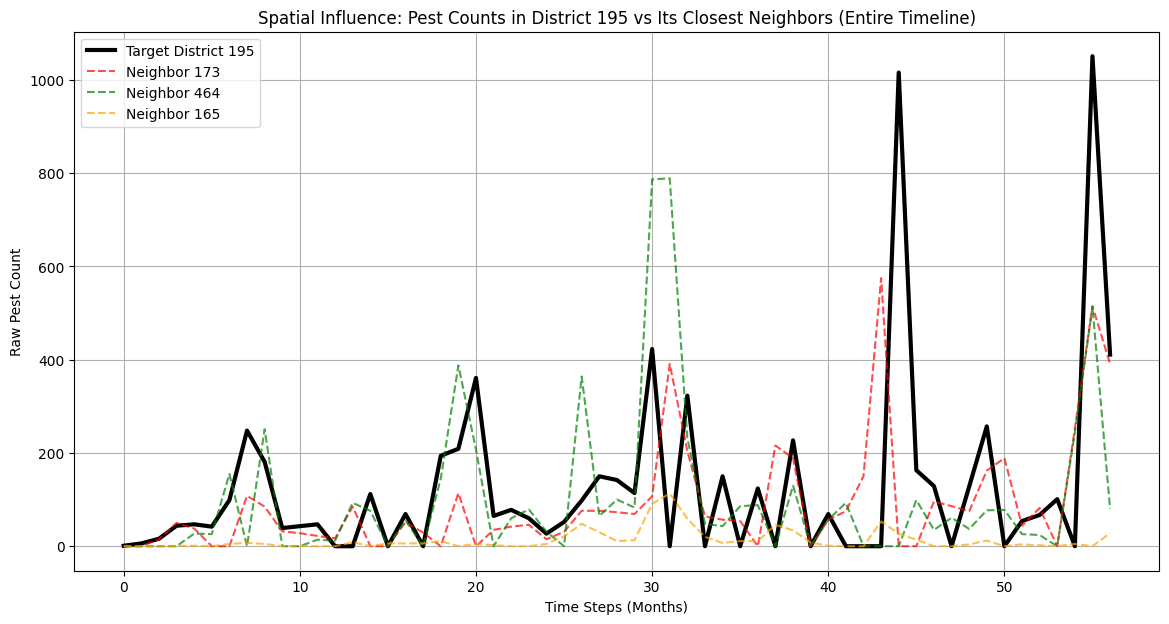

In [15]:
# Let's analyze the same district we visualized above
target_district = district_idx

# Find all neighbors of the target district from the edge_index
# edge_index shape is (2, num_edges). Row 0 is source, Row 1 is destination.
sources = edge_index[0]
destinations = edge_index[1]

# Find where the target district is the destination
neighbor_indices = sources[destinations == target_district]

print(f"Target District: {target_district}")
print(f"Number of immediate neighbors: {len(neighbor_indices)}")
print(f"Neighbor District IDs: {neighbor_indices}")

# Let's plot the actual pest counts of the target district vs its top 3 closest neighbors
# We can use edge_weight to find the closest ones (assuming higher weight = closer/more impact)
weights_to_target = edge_weight[destinations == target_district]

# Sort neighbors by weight (descending)
sorted_indices = np.argsort(weights_to_target)[::-1]
top_neighbors = neighbor_indices[sorted_indices][:3]

plt.figure(figsize=(14, 7))

# Plot Target District (using the entire timeline from data_matrix, not just test set)
# data_matrix shape is (num_nodes, num_time_steps) -> (543, 57)
target_data = data_matrix[target_district, :]
plt.plot(target_data, label=f'Target District {target_district}', color='black', linewidth=3)

# Plot Top Neighbors
colors = ['red', 'green', 'orange']
for i, neighbor in enumerate(top_neighbors):
    neighbor_data = data_matrix[neighbor, :]
    plt.plot(neighbor_data, label=f'Neighbor {neighbor}', color=colors[i], linestyle='--', alpha=0.7)

plt.title(f'Spatial Influence: Pest Counts in District {target_district} vs Its Closest Neighbors (Entire Timeline)')
plt.xlabel('Time Steps (Months)')
plt.ylabel('Raw Pest Count')
plt.legend()
plt.grid(True)
plt.show()

## 9. Refining the Graph: K-Nearest Neighbors (KNN) Only
You made a great point: **only the nearest districts should influence the pest attacks**. If a district is too far away, its data might just be adding "noise" to our model.

Right now, our graph might have too many connections. Let's explicitly prune the graph so that every district is ONLY connected to its **Top 3 nearest neighbors**. Then, we will retrain the model on this localized graph to see if it improves our predictions!

In [18]:
def get_knn_graph(edge_index, edge_weight, k=3):
    """
    Filters the graph to keep only the top K nearest neighbors for each node.
    Assuming higher edge_weight means a stronger/closer connection.
    """
    sources = edge_index[0]
    destinations = edge_index[1]
    
    new_sources = []
    new_destinations = []
    new_weights = []
    
    num_nodes = int(edge_index.max()) + 1
    
    for node in range(num_nodes):
        # Find all edges where 'node' is the destination
        mask = (destinations == node)
        node_sources = sources[mask]
        node_weights = edge_weight[mask]
        
        if len(node_sources) == 0:
            continue
            
        # Sort by weight descending (highest weight = closest neighbor)
        sorted_idx = np.argsort(node_weights)[::-1]
        
        # Keep only the top K
        top_k_idx = sorted_idx[:k]
        
        new_sources.extend(node_sources[top_k_idx])
        new_destinations.extend([node] * len(top_k_idx))
        new_weights.extend(node_weights[top_k_idx])
        
    return np.array([new_sources, new_destinations]), np.array(new_weights)

# Create the KNN Graph (K=3)
k_neighbors = 5
knn_edge_index, knn_edge_weight = get_knn_graph(edge_index, edge_weight, k=k_neighbors)

print(f"Original number of edges: {edge_index.shape[1]}")
print(f"New number of edges (Top {k_neighbors} only): {knn_edge_index.shape[1]}")

# Convert to PyTorch tensors
knn_edge_index_tensor = torch.LongTensor(knn_edge_index)
knn_edge_weight_tensor = torch.FloatTensor(knn_edge_weight)

Original number of edges: 4306
New number of edges (Top 5 only): 2663


Training STGNN on KNN Graph...
Epoch [20/100] | KNN-STGNN Loss: 0.0010
Epoch [40/100] | KNN-STGNN Loss: 0.0008
Epoch [60/100] | KNN-STGNN Loss: 0.0007
Epoch [80/100] | KNN-STGNN Loss: 0.0007
Epoch [100/100] | KNN-STGNN Loss: 0.0007

KNN-STGNN R2 Score for District 195: -0.1659


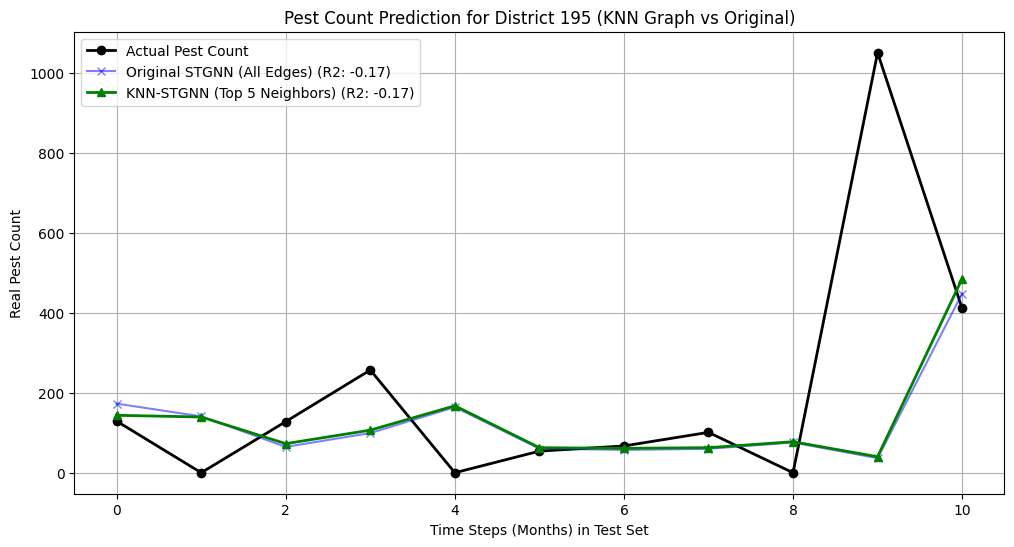

In [19]:
# Initialize a new STGNN model specifically for the KNN graph
knn_stgnn_model = STGNN(hidden_channels, out_channels)
opt_knn_stgnn = optim.AdamW(knn_stgnn_model.parameters(), lr=0.005)

knn_stgnn_losses = []

print("Training STGNN on KNN Graph...")
for epoch in range(epochs):
    knn_stgnn_model.train()
    opt_knn_stgnn.zero_grad()
    
    # Pass the NEW knn_edge_index and knn_edge_weight
    out_knn = knn_stgnn_model(X_train_tensor, knn_edge_index_tensor, knn_edge_weight_tensor)
    
    loss_knn = criterion(out_knn, y_train_tensor)
    loss_knn.backward()
    opt_knn_stgnn.step()
    
    knn_stgnn_losses.append(loss_knn.item())
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | KNN-STGNN Loss: {loss_knn.item():.4f}')

# Evaluate the new model
knn_stgnn_model.eval()
with torch.no_grad():
    test_knn = knn_stgnn_model(X_test_tensor, knn_edge_index_tensor, knn_edge_weight_tensor)
    
# Inverse transform predictions
pred_knn_scaled = test_knn[:, district_idx, 0].numpy()
pred_knn = scaler.inverse_transform(pred_knn_scaled.reshape(-1, 1)).flatten()

# Calculate new R2 Score
r2_knn = r2_score(actual, pred_knn)
print(f"\nKNN-STGNN R2 Score for District {district_idx}: {r2_knn:.4f}")

# Plot the comparison
plt.figure(figsize=(12, 6))
plt.plot(actual, label='Actual Pest Count', marker='o', color='black', linewidth=2)
plt.plot(pred_stgnn, label=f'Original STGNN (All Edges) (R2: {r2_stgnn:.2f})', marker='x', color='blue', alpha=0.5)
plt.plot(pred_knn, label=f'KNN-STGNN (Top {k_neighbors} Neighbors) (R2: {r2_knn:.2f})', marker='^', color='green', linewidth=2)
plt.title(f'Pest Count Prediction for District {district_idx} (KNN Graph vs Original)')
plt.xlabel('Time Steps (Months) in Test Set')
plt.ylabel('Real Pest Count')
plt.legend()
plt.grid(True)
plt.show()